In [1]:
import numpy as np 
import matplotlib.pyplot as plt
import json as js

In [21]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
#plt.rcParams['figure.dpi'] = 150  # ou 200

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",  # Computer Modern par défaut
    "font.serif": ["Computer Modern"],  # Facultatif, plus explicite
    "axes.labelsize": 14,
    "font.size": 14,
    "legend.fontsize": 12,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
})

In [9]:
with open("DATA_Cluster/ErrorAgainstTaubeta10.json", "r") as file:
    dic = js.load(file)

beta_list = dic["beta list"]
tau_list = dic["tau list"]

print(dic.keys())

dict_keys(['maximum bond dimension per tebd step', 'magnet', 'axis', 'model', 'energy', 'axis spin', 'tau list', 'Dmax', 'cutoff', 'J', 'disorder', 'upper boundary beta', 'beta list', 'N', 'proportion spin average', 'step beta list'])


In [4]:
def error(y_data, exact_data):
    if exact_data == 0:
        return y_data
    error_value = (y_data-exact_data)/exact_data
    return error_value

from scipy.integrate import quad

def exact_energy_XY(beta, h=0.0, gamma=0.0):
    def epsilon(k, h, gamma):
        return np.sqrt((np.cos(k) - h)**2 + (gamma * np.sin(k))**2)
    
    def integrand(k):
        e = epsilon(k, h, gamma)
        return e * np.tanh(0.5 * beta * e) / (2 * np.pi)
    
    val, _ = quad(integrand, -np.pi, np.pi, epsrel=1e-9)
    return -val / 2

exact_energy_list = np.array([exact_energy_XY(beta) for beta in beta_list])

In [66]:
mean_energy_site = np.mean(dic["energy"], axis=2)
mean_magnet_site = np.mean(dic["magnet"], axis=2)

print("shape average energy over sites", np.shape(mean_energy_site))
print("shape average magnet over sites", np.shape(mean_magnet_site))
print("number of beta = ", len(beta_list))
print("number of tau = ", len(tau_list))

beta5index = 1 + 5*10
beta2index = 1 + 2*10

print(np.shape(mean_energy_site[:,:beta5index]))

dist_tau_energy_beta10 = np.linalg.norm(mean_energy_site - exact_energy_list[None ,:], axis=1)
dist_tau_energy_beta5 = np.linalg.norm(mean_energy_site[:,:beta5index] - exact_energy_list[None ,:beta5index], axis=1)
dist_tau_energy_beta2 = np.linalg.norm(mean_energy_site[:,:beta2index] - exact_energy_list[None ,:beta2index], axis=1)

print("shape de erreur en fonction de tau", np.shape(dist_tau_energy_beta10))

shape average energy over sites (5, 101)
shape average magnet over sites (5, 101)
number of beta =  101
number of tau =  5
(5, 51)
shape de erreur en fonction de tau (5,)


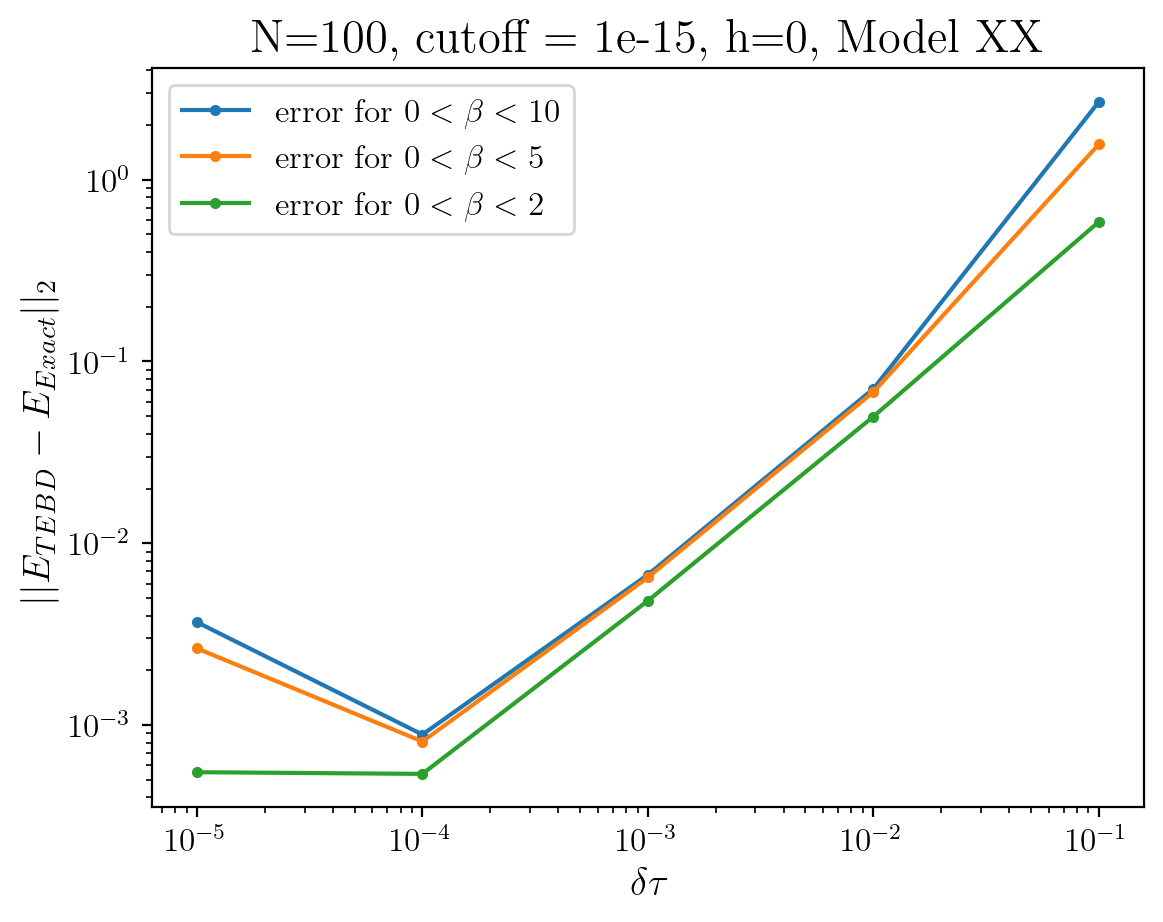

In [78]:
fig, ax = plt.subplots()
ax.loglog(tau_list[:], dist_tau_energy_beta10[:], label=r"error for $0<\beta<10$", marker='.')
ax.loglog(tau_list[:], dist_tau_energy_beta5[:], label=r"error for $0<\beta<5$", marker='.')
ax.loglog(tau_list[:], dist_tau_energy_beta2[:], label=r"error for $0<\beta<2$", marker='.')
ax.set_xlabel(r"$\delta\tau$")
ax.set_ylabel(r"$||E_{TEBD}-E_{Exact}||_2$")
ax.set_title("N={}, cutoff = 1e-15, h={}, Model XX".format(dic["N"], dic["disorder"]))
ax.legend()
plt.savefig("../run/Plots/errorglobalenergydeltatau.pdf")
plt.show()

In [75]:
error_beta_tau = {}

for i in range(len(tau_list)):
    error_beta_tau[f"energy tau = {tau_list[i]}"] = np.array([error(mean_energy_site[i, :][k], exact_energy_list[k]) for k in range(len(exact_energy_list))])

error_beta_tau
print(len(error_beta_tau["energy tau = 0.1"]))

101


<function matplotlib.pyplot.show(close=None, block=None)>

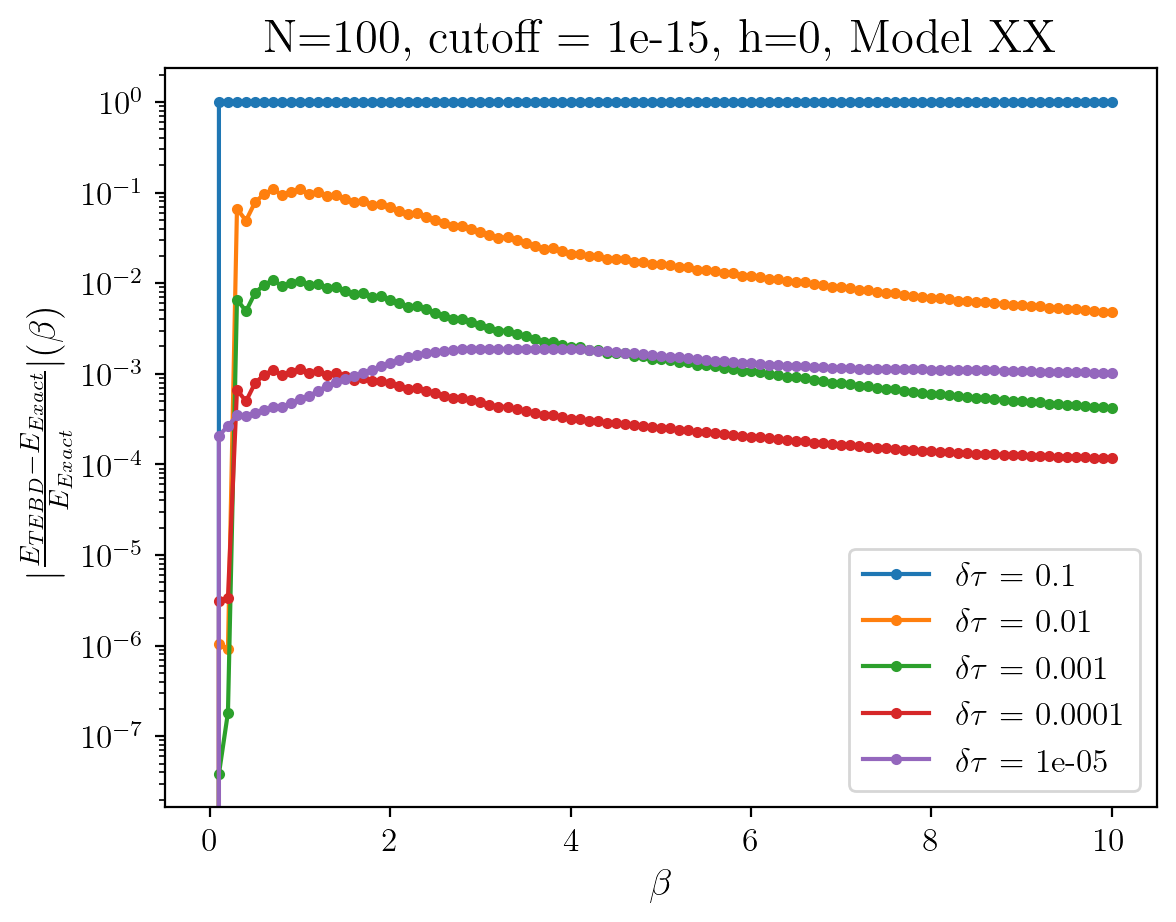

In [92]:
fig, ax = plt.subplots()
for i in range(len(tau_list)):
    ax.semilogy(beta_list, np.abs(error_beta_tau[f"energy tau = {tau_list[i]}"]), label = r"$\delta\tau$ = {}".format(tau_list[i]), marker='.')
ax.set_xlabel(r"$\beta$")
ax.set_ylabel(r"$|\frac{E_{TEBD}-E_{Exact}}{E_{Exact}}|(\beta)$")
ax.set_title("N={}, cutoff = 1e-15, h={}, Model XX".format(dic["N"], dic["disorder"]))
ax.legend()
plt.savefig("../run/Plots/errorenergydeltatauagainstbeta.pdf")
plt.legend()
plt.show


In [96]:
dist_tau_magnet_beta10 = np.linalg.norm(mean_magnet_site, axis=1)
dist_tau_magnet_beta5 = np.linalg.norm(mean_magnet_site[:,:beta5index], axis=1)
dist_tau_magnet_beta2 = np.linalg.norm(mean_magnet_site[:,:beta2index], axis=1)

print(np.shape(mean_magnet_site))

for i in range(len(tau_list)):
    error_beta_tau[f"magnet tau = {tau_list[i]}"] = mean_magnet_site[i, :]

(5, 101)


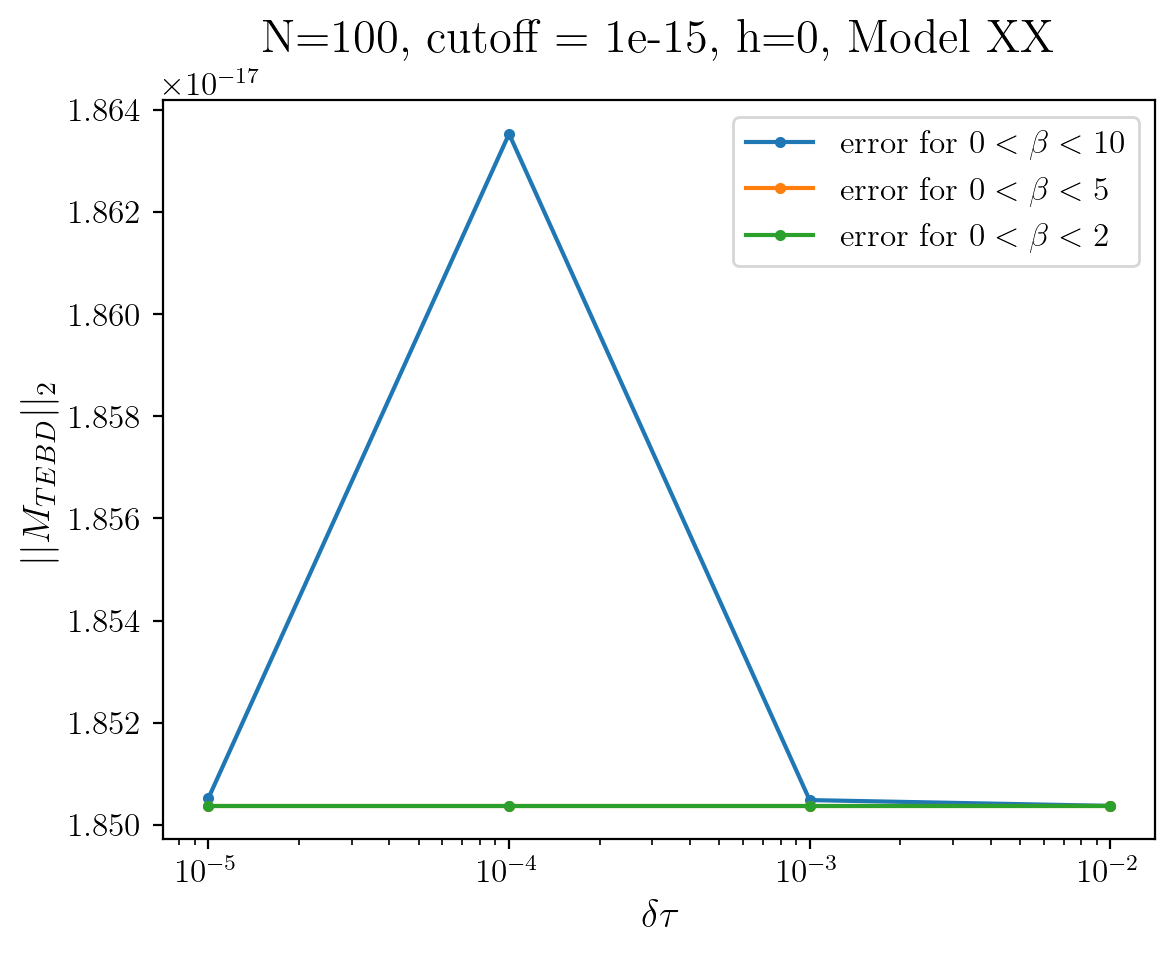

In [90]:
fig, ax = plt.subplots()
ax.semilogx(tau_list[1:], dist_tau_magnet_beta10[1:], label=r"error for $0<\beta<10$", marker='.')
ax.semilogx(tau_list[1:], dist_tau_magnet_beta5[1:], label=r"error for $0<\beta<5$", marker='.')
ax.semilogx(tau_list[1:], dist_tau_magnet_beta2[1:], label=r"error for $0<\beta<2$", marker='.')

ax.set_xlabel(r"$\delta\tau$")
ax.set_ylabel(r"$||M_{TEBD}||_2$")
ax.set_title("N={}, cutoff = 1e-15, h={}, Model XX".format(dic["N"], dic["disorder"]))
ax.legend()
plt.savefig("../run/Plots/errorglobalmagnetdeltatau.pdf")
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

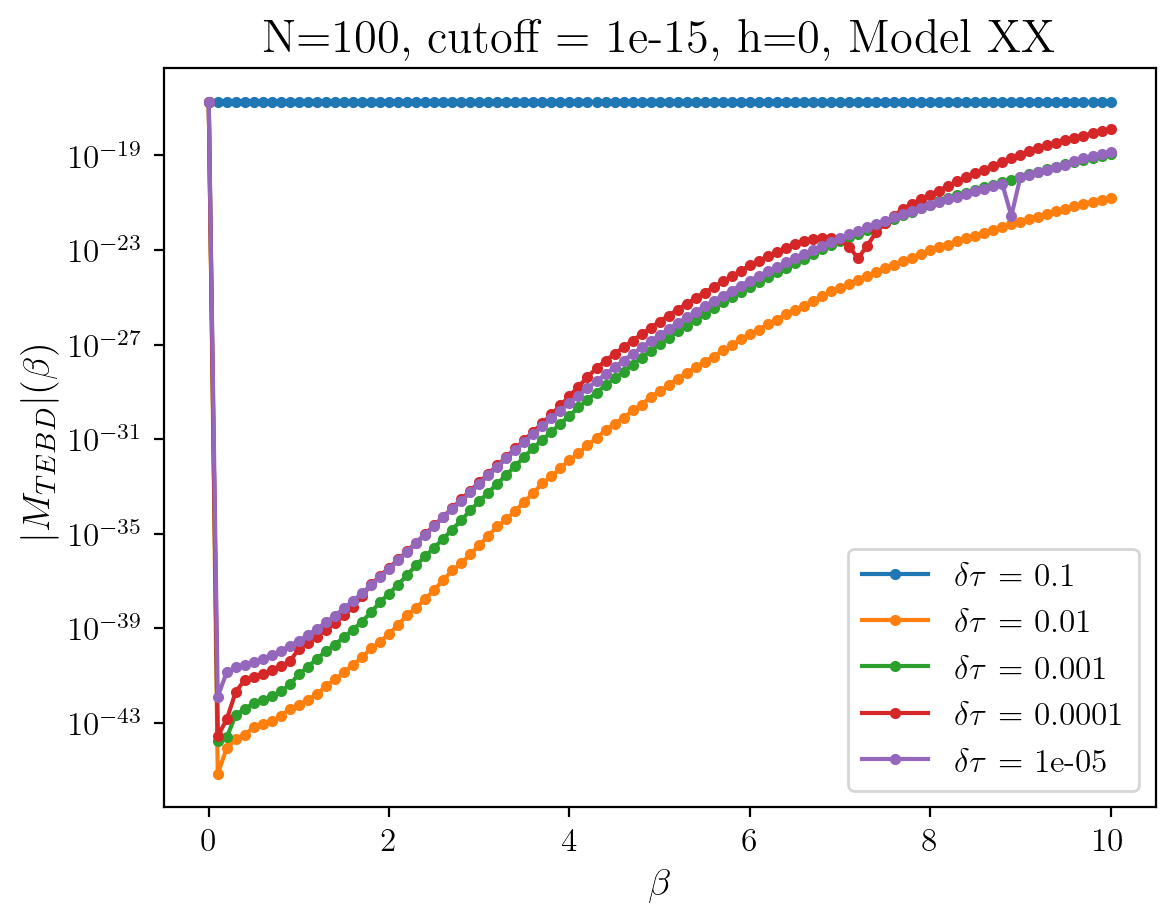

In [97]:
fig, ax = plt.subplots()
for i in range(len(tau_list)):
    ax.semilogy(beta_list, np.abs(error_beta_tau[f"magnet tau = {tau_list[i]}"]), label = r"$\delta\tau$ = {}".format(tau_list[i]), marker='.')
ax.set_xlabel(r"$\beta$")
ax.set_ylabel(r"$|M_{TEBD}|(\beta)$")
ax.set_title("N={}, cutoff = 1e-15, h={}, Model XX".format(dic["N"], dic["disorder"]))
ax.legend()
plt.savefig("../run/Plots/errormagnetdeltatauagainstbeta.pdf")
plt.legend()
plt.show

In [99]:
with open("DATA_Cluster/verifcodebeta40N100.json", "r") as file:
    dicdisorder = js.load(file)

print(dicdisorder.keys())

dict_keys(['maximum bond dimension per tebd step', 'exact energy exact', 'Trotter-Suzuki time step', 'beta fixe', 'n_sweepDMRG', 'axis spin', 'energy sites dmrg', 'Dmax', 'initial bond dimension', 'J', 'cutoff', 'disorder', 'magnet sites dmrg', 'N', 'energy sites tebd', 'magnet sites tebd', 'exact energy', 'liste sites', 'proportion spin average', 'exact energy dmrg'])


In [100]:
N = 100
gammescale = 0.8

print(len(dicdisorder["liste sites"]))

81


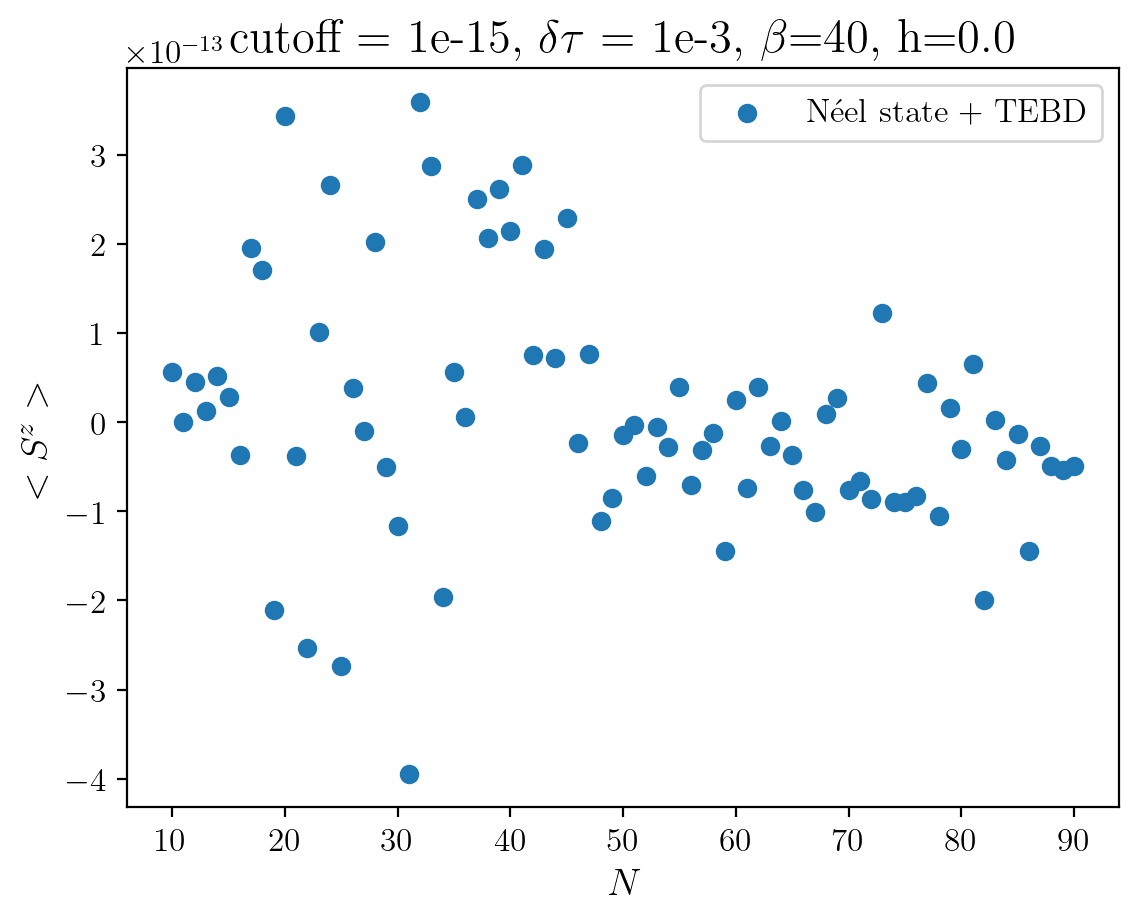

In [101]:
fig, axes = plt.subplots()
axes.scatter(dicdisorder["liste sites"], dicdisorder["magnet sites tebd"], label="Néel state + TEBD")
axes.set_xlabel(r"$N$")
axes.set_ylabel(r"$<S^z>$")
axes.set_title(r"cutoff = 1e-15, $\delta\tau$ = 1e-3, $\beta$=40, h={}".format(dicdisorder["disorder"]))
axes.legend()
#plt.savefig("../run/Plots/verifcodemagnetbeta40.pdf")
plt.show()

In [102]:
mean_tebd = np.mean(dicdisorder["energy sites tebd"])
mean_dmrg = np.mean(dicdisorder["energy sites dmrg"])
std_tebd = np.std(dicdisorder["energy sites tebd"])
std_dmrg = np.std(dicdisorder["energy sites dmrg"])

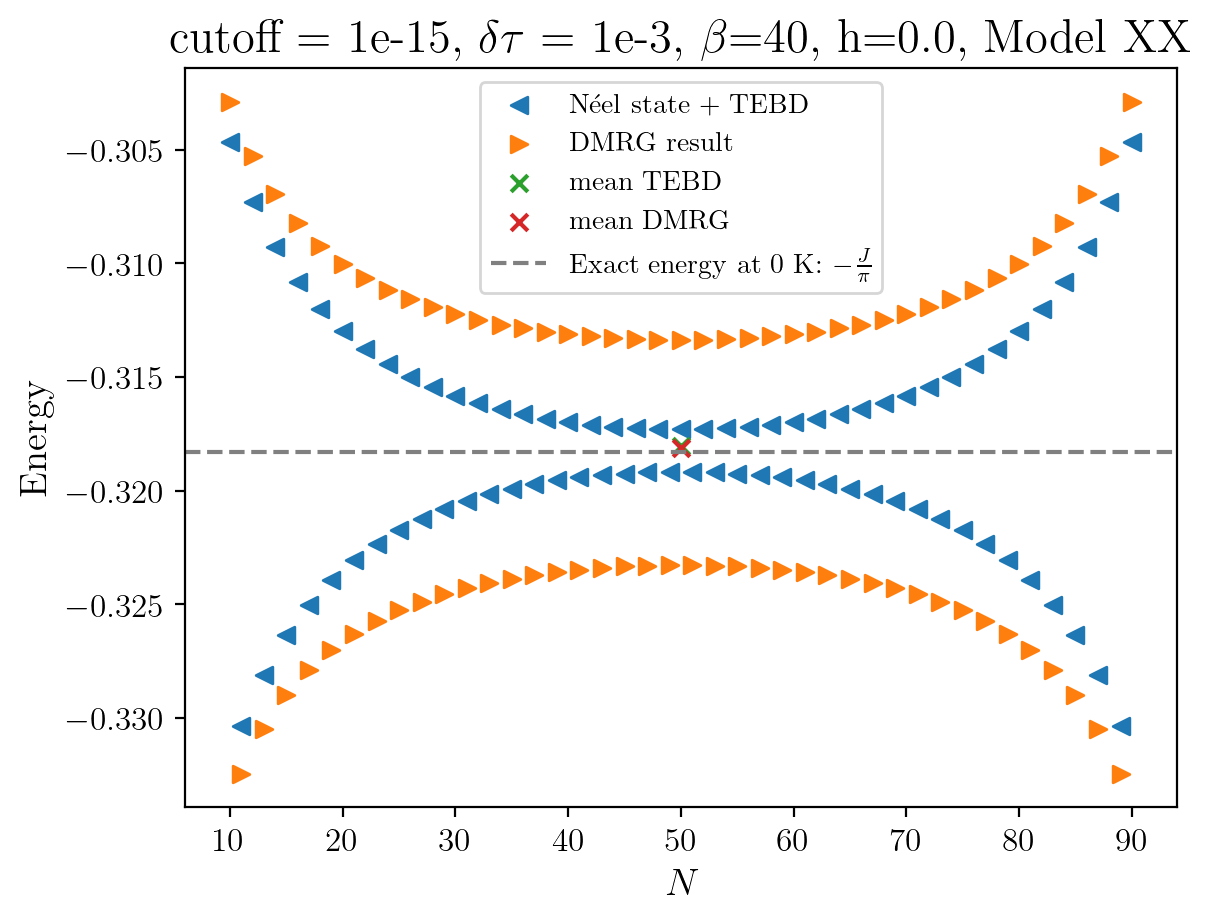

In [116]:
fig, axes = plt.subplots()
axes.scatter(dicdisorder["liste sites"], dicdisorder["energy sites tebd"], label="Néel state + TEBD", marker='<')
axes.set_xlabel(r"$N$")
axes.set_ylabel("Energy")
axes.scatter(dicdisorder["liste sites"], dicdisorder["energy sites dmrg"], label="DMRG result", marker='>')
axes.set_title(r"cutoff = 1e-15, $\delta\tau$ = 1e-3, $\beta$=40, h={}, Model XX".format(dicdisorder["disorder"]))
axes.scatter([50], mean_tebd, label="mean TEBD", marker='x')
axes.scatter([50], mean_dmrg, label="mean DMRG", marker='x')
axes.axhline(y=-1/np.pi, label=r"Exact energy at 0 K: $-\frac{J}{\pi}$", color='grey', linestyle='--')
axes.legend(fontsize=10)
plt.savefig("../run/Plots/verifcodeenergybeta40.pdf")
plt.show()

In [105]:
error = [(dicdisorder["energy sites tebd"][k] - dicdisorder["energy sites dmrg"][k])/dicdisorder["energy sites dmrg"][k] for k in range(len(dicdisorder["energy sites dmrg"]))]

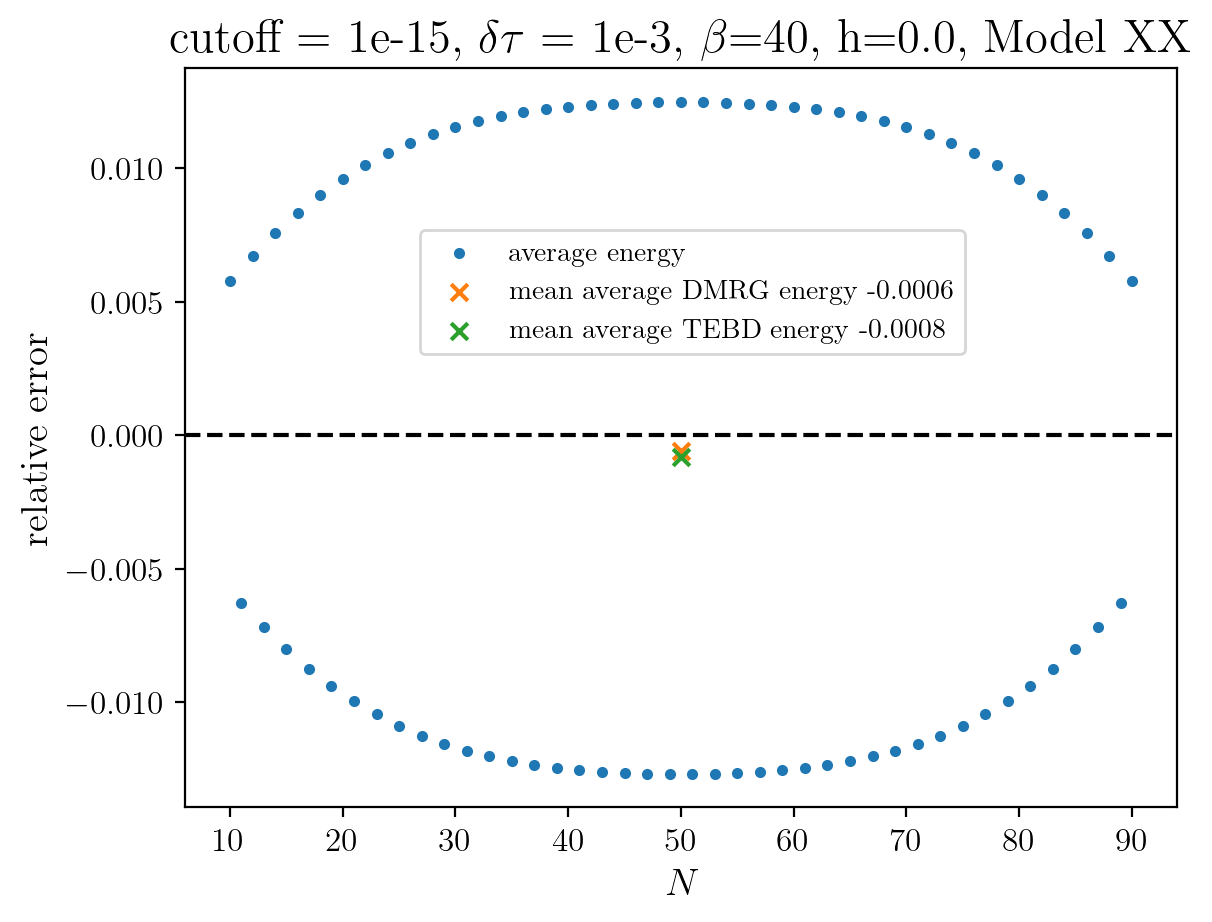

In [129]:
exact = -1/np.pi
error_tebd = (mean_tebd-exact)/exact
error_dmrg = (mean_dmrg-exact)/exact

fig, axes = plt.subplots()
axes.scatter(dicdisorder["liste sites"], error, label="average energy", marker='.')
axes.set_xlabel(r"$N$")
axes.set_ylabel("relative error")
axes.set_title(r"cutoff = 1e-15, $\delta\tau$ = 1e-3, $\beta$=40, h={}, Model XX".format(dicdisorder["disorder"]))
axes.scatter([50], error_dmrg, label="mean average DMRG energy {:.4f}".format(error_dmrg), marker='x')
axes.scatter([50], error_tebd, label="mean average TEBD energy {:.4f}".format(error_tebd), marker='x')
axes.legend(fontsize=10, loc='upper right', bbox_to_anchor=(0.8,0.8))
axes.axhline(y=0, color='black', linestyle='--')
plt.savefig("../run/Plots/verifcodeerrorbeta40.pdf")
plt.show()